# Система детекции аномалий и динамического ценообразования

## Цель

Решение состоит из двух связанных частей:

1. Найти технически подозрительные значения `sales` и показать, какие наблюдаемые факторы объясняют ожидаемый спрос.
2. Построить прогноз спроса на один день вперёд и подобрать цены для трёх разных целей: продажи, GMV и прибыль.

Ключевой принцип решения — **временная корректность**. Все лаги и rolling-статистики используют только прошлые наблюдения. Скрытая колонка `is_anomaly_label` не используется при построении score, признаков или моделей; она нужна только для финальной проверки детектора.

### Основные допущения

- На следующий день известны план промо, рекламный бюджет, текущая цена конкурента и доступный остаток. В демонстрационном сценарии промо выключено, а неизвестные внешние признаки заменены последними устойчивыми значениями.
- `latent_trend_val` исключён: скрытый будущий тренд нельзя гарантированно получить в production.
- `feat_00...feat_12` исключены, поскольку у них нет бизнес-семантики и способа воспроизведения online.
- `stock_level` используется как признак, но не как жёсткий cap: в данных продажи часто превышают остаток, поэтому семантика среза остатка неоднозначна.
- Наблюдательные данные не доказывают причинный эффект цены. Эластичность регуляризуется, ограничивается по знаку, а запуск рекомендаций должен проходить через A/B-тест.

In [1]:
import os
import sys
from pathlib import Path

ROOT = Path.cwd()
if (ROOT / "retail_mle_task_data.parquet").exists():
    PROJECT_DIR = ROOT
elif (ROOT / "ml-interview-task" / "retail_mle_task_data.parquet").exists():
    PROJECT_DIR = ROOT / "ml-interview-task"
else:
    raise FileNotFoundError("Не найден retail_mle_task_data.parquet")

os.environ.setdefault("MPLCONFIGDIR", str(PROJECT_DIR / ".mplconfig"))
(PROJECT_DIR / ".mplconfig").mkdir(exist_ok=True)
sys.path.insert(0, str(PROJECT_DIR))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from retail_pricing.anomaly import detector_metrics, score_anomalies
from retail_pricing.data import data_quality_report, load_dataset
from retail_pricing.demand import fit_final_demand_model, walk_forward_validation
from retail_pricing.elasticity import estimate_elasticities
from retail_pricing.explainability import root_cause_report
from retail_pricing.features import build_model_frame
from retail_pricing.optimization import optimize_prices

pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")
plt.style.use("seaborn-v0_8-whitegrid")

DATA_PATH = PROJECT_DIR / "retail_mle_task_data.parquet"
ARTIFACT_DIR = PROJECT_DIR / "artifacts"
ARTIFACT_DIR.mkdir(exist_ok=True)
SEED = 42

## 1. Аудит данных

Перед моделированием проверим полноту панели, пропуски, дубликаты и бизнес-ограничения. Проверка `sales_lag_1` сравнивает готовую колонку с фактическим сдвигом ряда; при расхождениях далее всё равно используются собственные причинные лаги.

In [2]:
dataset = load_dataset(DATA_PATH)
quality = data_quality_report(dataset)

print(f"Период: {dataset['date'].min().date()} — {dataset['date'].max().date()}")
print(f"Форма: {dataset.shape}; товаров: {dataset['item_id'].nunique()}")
display(quality)

category_summary = (
    dataset.groupby("category")
    .agg(
        items=("item_id", "nunique"),
        rows=("item_id", "size"),
        mean_sales=("sales", "mean"),
        median_sales=("sales", "median"),
        mean_price=("price", "mean"),
        promo_rate=("promo_active", "mean"),
    )
    .sort_values("mean_sales", ascending=False)
)
display(category_summary)

Период: 2022-01-01 — 2023-12-31
Форма: (146000, 33); товаров: 200


,check,value
0,rows,146000
1,expected_full_panel_rows,146000
2,items,200
3,dates,730
4,missing_values,0
5,duplicate_item_dates,0
6,negative_sales,0
7,nonpositive_prices,0
8,price_below_cost,2951
9,sales_above_stock,38469


,items,rows,mean_sales,median_sales,mean_price,promo_rate
category,,,,,,
Groceries,38,27740,"1,323.2916",84.0000,486.6215,0.0493
Home & Kitchen,39,28470,"1,290.7909",23.5000,397.2030,0.0493
Beauty,43,31390,"1,203.9568",31.0000,466.0409,0.0493
Fashion,35,25550,893.3979,10.0000,374.6971,0.0493
Electronics,45,32850,877.3059,24.0000,468.0325,0.0493


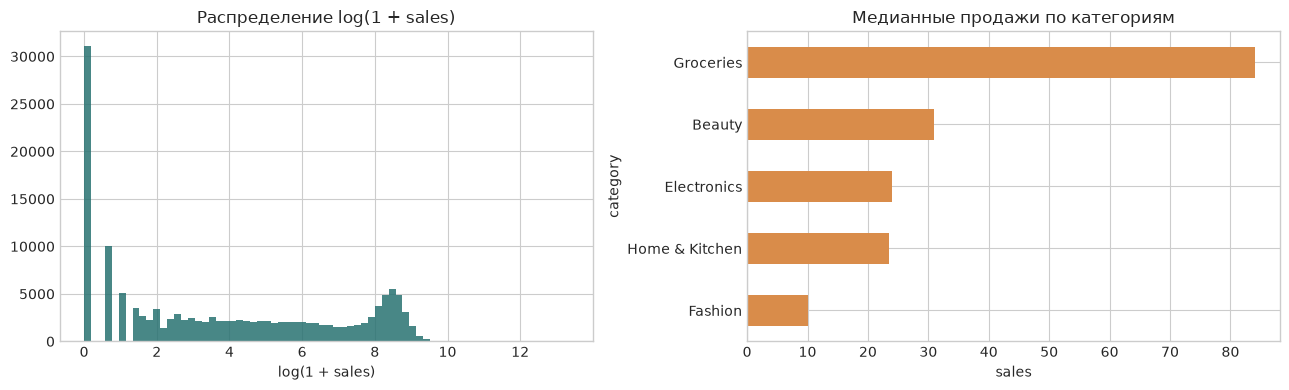

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(np.log1p(dataset["sales"]), bins=70, color="#287271", alpha=0.85)
axes[0].set_title("Распределение log(1 + sales)")
axes[0].set_xlabel("log(1 + sales)")

dataset.groupby("category")["sales"].median().sort_values().plot(
    kind="barh", ax=axes[1], color="#D98C4A"
)
axes[1].set_title("Медианные продажи по категориям")
axes[1].set_xlabel("sales")
plt.tight_layout()
plt.show()

## 2. Детекция аномалий

Для каждого товара вычисляется локальное ожидание по предыдущим 28 дням. Основной score:

$$
score_{i,t}=\frac{|y_{i,t}-\mu_{i,t}^{(28)}|}
{\sigma_{i,t}^{(28)}+\sqrt{\mu_{i,t}^{(28)}+1}}.
$$

Добавка $\sqrt{\mu+1}$ стабилизирует score на малых продажах. Положительный порог задаётся 99.9-м перцентилем `spike_score`, рассчитанным только по датам, предшествующим текущей. Обычный всплеск в промо-день считается объяснимым бизнес-событием; в high-confidence алерт он попадает только при превышении порога в 10 раз. Для провалов есть отдельное правило review-уровня: ноль считается подозрительным, если локальное среднее не меньше 15 и товар продавался более чем в 90% предыдущих дней.

Получаются два уровня: высокоточные технические всплески для немедленного алерта и более широкий список review-кандидатов. Для общего ranking промо-всплески понижаются, а неожиданные нули поднимаются до уровня текущего порога.

In [4]:
scored = score_anomalies(dataset)
detector_report = detector_metrics(scored)

print(f"Порог spike_score на последнюю дату: {scored.attrs['latest_spike_threshold']:.3f}")
print(f"High-confidence алертов: {scored['is_high_confidence_anomaly'].sum():,}")
print(f"Всего review-кандидатов: {scored['is_candidate_anomaly'].sum():,}")
display(detector_report)

detected = scored[scored["is_candidate_anomaly"]].sort_values(
    "ranking_score", ascending=False
)
display(
    detected[
        [
            "date",
            "item_id",
            "sales",
            "local_mean_28",
            "ranking_score",
            "anomaly_type",
        ]
    ].head(20)
)

Порог spike_score на последнюю дату: 14.878
High-confidence алертов: 16
Всего review-кандидатов: 55


,metric,value
0,average_precision,0.8785
1,roc_auc,0.9344
2,high_confidence_precision,1.0000
3,high_confidence_recall,0.8000
4,high_confidence_f1,0.8889
5,high_confidence_rows,16.0000
6,review_precision,0.3273
7,review_recall,0.9000
8,review_f1,0.4800
9,review_rows,55.0000


,date,item_id,sales,local_mean_28,ranking_score,anomaly_type
23808,2023-03-25,ITEM_032,10000,0.1429,"7,015.5074",technical_spike
128870,2023-01-26,ITEM_176,10000,0.2500,"6,111.4884",technical_spike
19825,2022-04-26,ITEM_027,10200,0.2857,"5,523.5401",technical_spike
110474,2022-09-02,ITEM_151,10100,0.7500,"4,486.8877",technical_spike
7055,2023-05-01,ITEM_009,10100,0.5000,"4,334.0165",technical_spike
107699,2023-01-25,ITEM_147,10700,3.3929,"2,335.2370",technical_spike
118891,2023-09-24,ITEM_162,10800,4.6429,"1,446.8075",technical_spike
40750,2023-08-24,ITEM_055,10400,6.8571,"1,388.8427",technical_spike
51991,2022-06-11,ITEM_071,10400,11.8571,542.3022,technical_spike
109379,2023-09-02,ITEM_149,21600,52.2857,423.1186,technical_spike


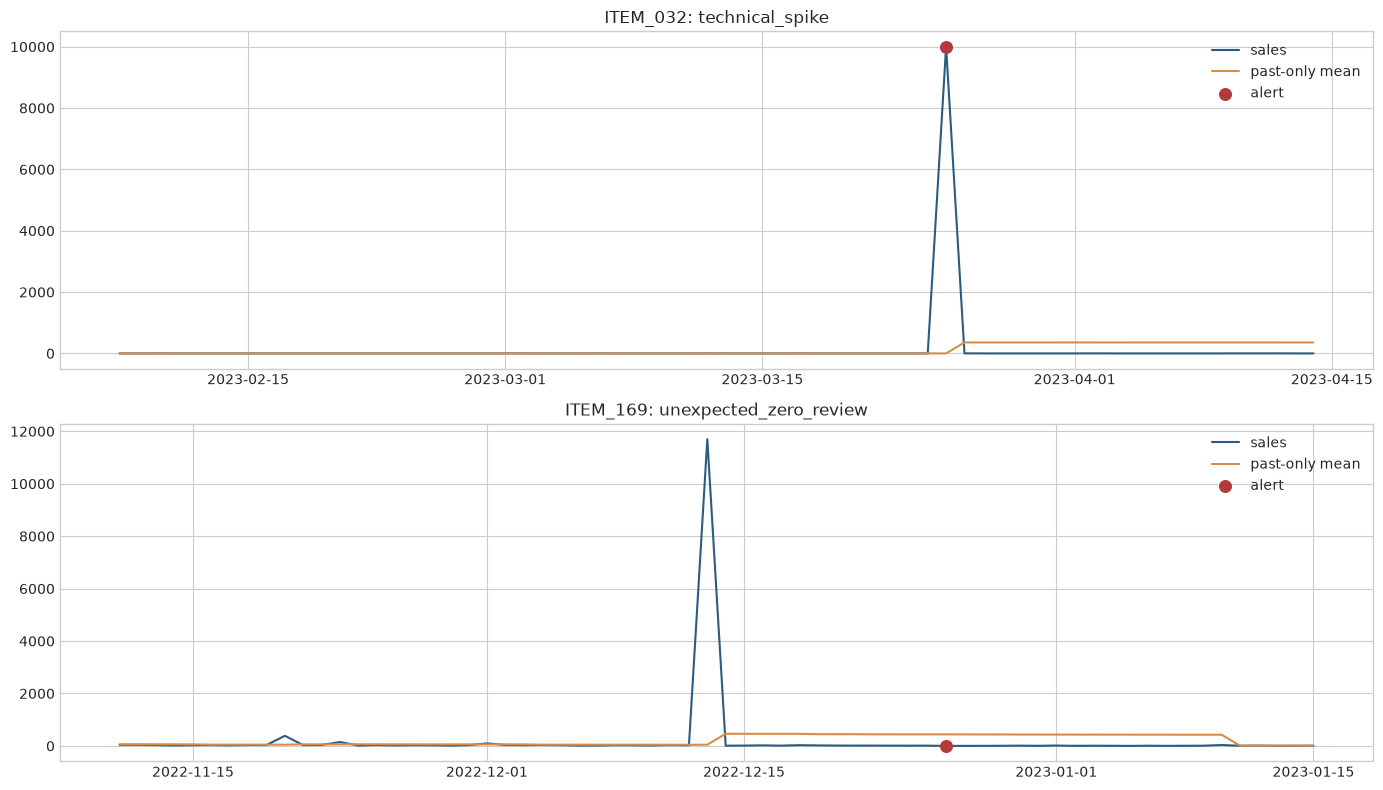

In [5]:
spike_event = detected[detected["anomaly_type"].eq("technical_spike")].iloc[0]
drop_event = (
    detected[detected["anomaly_type"].eq("unexpected_zero_review")]
    .sort_values("local_mean_28", ascending=False)
    .iloc[0]
)
events = [spike_event, drop_event]

fig, axes = plt.subplots(2, 1, figsize=(14, 8))
for ax, event in zip(axes, events):
    item = event["item_id"]
    center = event["date"]
    part = scored[
        scored["item_id"].eq(item)
        & scored["date"].between(center - pd.Timedelta(days=45), center + pd.Timedelta(days=20))
    ]
    ax.plot(part["date"], part["sales"], label="sales", color="#2A5C82")
    ax.plot(part["date"], part["local_mean_28"], label="past-only mean", color="#D98C4A")
    ax.scatter([center], [event["sales"]], color="#B33A3A", s=70, zorder=3, label="alert")
    ax.set_title(f"{item}: {event['anomaly_type']}")
    ax.legend()

plt.tight_layout()
plt.show()

### Интерпретация качества

`Average Precision` и `precision@K` уместнее accuracy: положительный класс крайне редок. Метрики считаются по контекстному `ranking_score`. Отдельно показываются precision/recall двух уровней: `high_confidence` и `review`. Скрытая разметка содержит также нулевые точки в прерывистых низкочастотных рядах; без журнала остатков и ETL-сбоев их нельзя надёжно отделить от нормальных нулей.

После детекции подозрительные значения заменяются локальной медианой **только при построении последующих лагов**. Это предотвращает каскад ложных прогнозов после технического всплеска. Сами строки-кандидаты исключаются из обучения спроса.

## 3. Модель спроса и временная валидация

Используется одна глобальная XGBoost-модель на все товары. Общая модель делит статистическую силу между рядами, а `item_id` и `category` сохраняют товарную неоднородность. Модель обучается непосредственно на `sales` с objective `reg:absoluteerror`: MAE-цель согласована с MAE/WAPE, а линейная абсолютная ошибка устойчивее квадратичной к тяжёлому хвосту. В сравнении на тех же временных фолдах этот вариант улучшил одновременно WAPE, SMAPE и RMSE относительно обучения на `log1p(sales)`.

Признаки:

- лаги, rolling median/mean, EWM и среднее по тому же дню недели;
- цена, себестоимость и относительная цена конкурента;
- исторический средний спрос в текущем promo-режиме и глубина скидки относительно 90-дневной медианы;
- промо и рекламный бюджет;
- остаток, погода и календарь;
- идентификатор товара и категория.

Валидация — три expanding-window фолда по 90 дней. В таблице показаны метрики как на всех строках, так и на строках, не помеченных нашим детектором.

In [6]:
model_frame = build_model_frame(scored)
validation = walk_forward_validation(model_frame)

validation_summary = (
    validation.metrics.groupby(["model", "scope"])[["MAE", "RMSE", "WAPE", "SMAPE"]]
    .mean()
    .sort_values("WAPE")
)
display(validation.metrics)
display(validation_summary)

,fold_start,model,scope,MAE,RMSE,WAPE,SMAPE
0,2023-04-01,rolling_mean_30,all_rows,528.7260,"1,219.7540",0.3624,0.5383
1,2023-04-01,rolling_mean_30,detector_clean_rows,528.1943,"1,217.4627",0.3621,0.5382
2,2023-04-01,xgboost_global,all_rows,505.1425,"1,215.5820",0.3462,0.4616
3,2023-04-01,xgboost_global,detector_clean_rows,504.6094,"1,213.2825",0.3460,0.4615
4,2023-07-01,rolling_mean_30,all_rows,554.0365,"1,292.6811",0.3575,0.5201
5,2023-07-01,rolling_mean_30,detector_clean_rows,549.5769,"1,241.2957",0.3556,0.5196
6,2023-07-01,xgboost_global,all_rows,533.5113,"1,299.8888",0.3443,0.4393
7,2023-07-01,xgboost_global,detector_clean_rows,529.0390,"1,248.5923",0.3423,0.4388
8,2023-10-01,rolling_mean_30,all_rows,593.8515,"1,325.3666",0.3655,0.5122
9,2023-10-01,rolling_mean_30,detector_clean_rows,593.9151,"1,325.4402",0.3655,0.5120


MAE       RMSE   WAPE  SMAPE
model           scope                                                
xgboost_global  detector_clean_rows 535.5207 1,262.7021 0.3470 0.4394
                all_rows            537.1685 1,280.5429 0.3477 0.4396
rolling_mean_30 detector_clean_rows 557.2288 1,261.3995 0.3611 0.5233
                all_rows            558.8714 1,279.2672 0.3618 0.5235

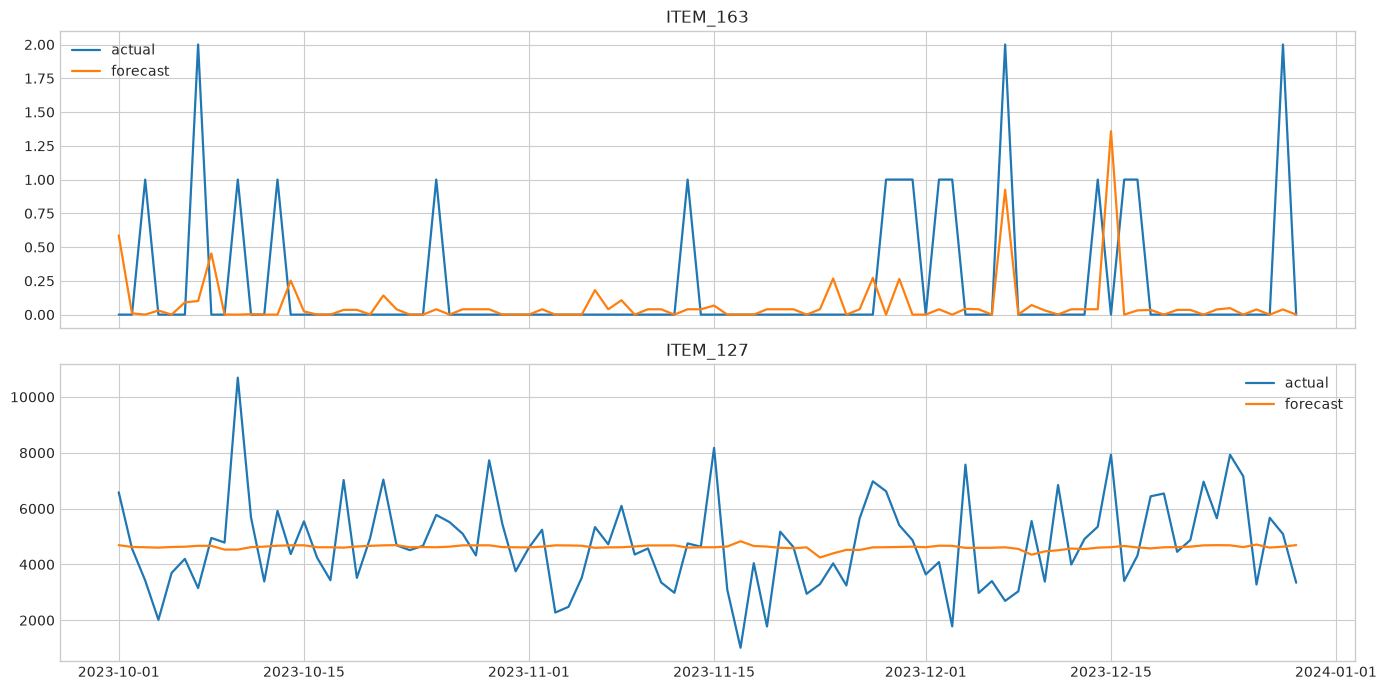

In [7]:
last_fold = validation.predictions["fold_start"].max()
plot_data = validation.predictions[validation.predictions["fold_start"].eq(last_fold)]
plot_items = (
    plot_data.groupby("item_id", observed=True)["sales"].mean().sort_values().iloc[[50, 150]].index
)

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
for ax, item_id in zip(axes, plot_items):
    part = plot_data[plot_data["item_id"].eq(item_id)].sort_values("date")
    ax.plot(part["date"], part["sales"], label="actual", linewidth=1.6)
    ax.plot(part["date"], part["prediction"], label="forecast", linewidth=1.6)
    ax.set_title(item_id)
    ax.legend()
plt.tight_layout()
plt.show()

## 4. Root Cause Analysis

Модель обучается заново на всей доступной истории без строк-кандидатов. Используется встроенный TreeSHAP XGBoost (`pred_contribs=True`), поэтому отдельная библиотека `shap` не требуется. Вклады выражены в единицах прогнозных продаж и агрегируются по бизнес-группам: история, цена, промо, конкуренция, доступность и календарные/внешние факторы.

Важно различать два вопроса:

1. **Что сформировало ожидаемый спрос?** На него отвечает крупнейший контекстный вклад.
2. **Объясняет ли контекст фактическую аномалию?** Если остаток на log-шкале очень велик, причиной считается `unexplained_residual`, а не фактор с самым большим SHAP.

Иными словами, SHAP объясняет прогноз модели, но не превращает технический выброс в бизнес-событие.

In [8]:
final_model = fit_final_demand_model(model_frame)
top_alerts = model_frame[model_frame["is_candidate_anomaly"]].nlargest(30, "ranking_score")
root_causes = root_cause_report(final_model, model_frame, top_alerts)

display(root_causes.head(20))
root_causes.to_csv(ARTIFACT_DIR / "root_cause_report.csv", index=False)

,date,item_id,category,sales,ranking_score,anomaly_type,expected_sales,actual_to_expected,largest_context_driver,driver_sales_effect,diagnosis
23808,2023-03-25,ITEM_032,Fashion,10000,"7,015.5074",technical_spike,0.0002,"10,000.0000",history,"-1,002.7664",unexplained_positive_residual
128870,2023-01-26,ITEM_176,Home & Kitchen,10000,"6,111.4884",technical_spike,0.0002,"10,000.0000",history,-995.0829,unexplained_positive_residual
19825,2022-04-26,ITEM_027,Fashion,10200,"5,523.5401",technical_spike,0.0000,"10,200.0000",history,-991.3945,unexplained_positive_residual
110474,2022-09-02,ITEM_151,Beauty,10100,"4,486.8877",technical_spike,0.2942,"10,100.0000",history,"-1,002.3344",unexplained_positive_residual
7055,2023-05-01,ITEM_009,Fashion,10100,"4,334.0165",technical_spike,0.0000,"10,100.0000",history,-988.2012,unexplained_positive_residual
107699,2023-01-25,ITEM_147,Beauty,10700,"2,335.2370",technical_spike,3.3209,"3,221.9960",history,-982.7003,unexplained_positive_residual
118891,2023-09-24,ITEM_162,Fashion,10800,"1,446.8075",technical_spike,4.6638,"2,315.6991",history,-988.6770,unexplained_positive_residual
40750,2023-08-24,ITEM_055,Groceries,10400,"1,388.8427",technical_spike,5.7894,"1,796.3776",history,-978.7159,unexplained_positive_residual
51991,2022-06-11,ITEM_071,Electronics,10400,542.3022,technical_spike,7.1785,"1,448.7773",history,-982.5407,unexplained_positive_residual
109379,2023-09-02,ITEM_149,Beauty,21600,423.1186,technical_spike,48.8341,442.3138,history,-929.1901,unexplained_positive_residual


## 5. Эластичность и динамическое ценообразование

Для товара $i$ используется локальная постоянная эластичность:

$$
\hat q_i(p)=\hat q_i(p_0)\left(\frac{p}{p_0}\right)^{\varepsilon_i}.
$$

`raw_elasticity` оценивается Ridge-регрессией на log-шкале с контролями промо, конкурента, рекламы, лагов, погоды и календаря. Из-за сильного observational confounding цена–промо часть сырых коэффициентов имеет неверный положительный знак. Поэтому автоматизированная политика использует:

- ограничение $-5 \le \varepsilon_i \le -0.05$;
- shrinkage к медиане категории, причём слабая вариативность цены усиливает shrinkage;
- сохранение сырой оценки для диагностики и дальнейшего эксперимента;
- маркировку `item_supported`/`category_prior_driven`: если знак или качество индивидуальной оценки ненадёжны, допустимое изменение цены дополнительно ограничивается 5%.

Это консервативная инженерная мера, а не замена причинному A/B-тесту.

,items,raw_median,production_median,median_r2,prior_driven_share
price_segment,,,,,
Budget,40,-0.5979,-0.4013,0.8268,0.3000
Economy,40,-0.2365,-0.4809,0.7454,0.5250
Luxury,40,0.0144,-0.3034,0.8532,0.5250
Premium,40,0.2875,-0.3245,0.8252,0.6250
Standard,40,-0.7586,-0.5643,0.7124,0.3500


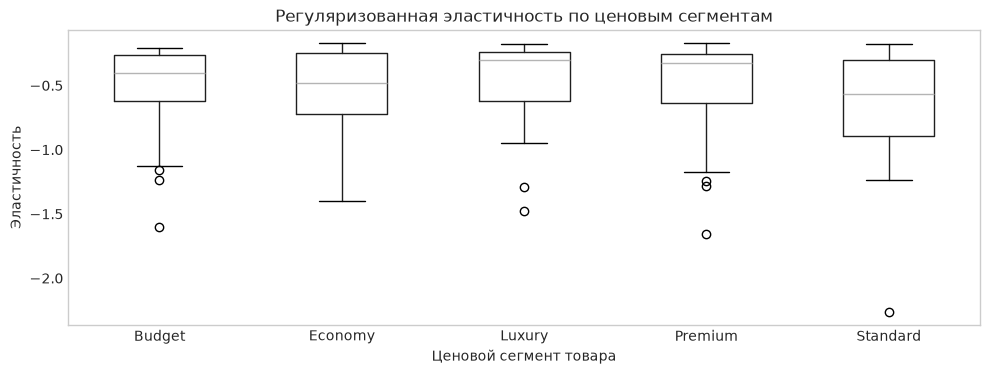

In [9]:
elasticity = estimate_elasticities(model_frame)
elasticity_summary = (
    elasticity.groupby("price_segment", observed=True)
    .agg(
        items=("item_id", "size"),
        raw_median=("raw_elasticity", "median"),
        production_median=("elasticity", "median"),
        median_r2=("model_r2", "median"),
        prior_driven_share=("elasticity_source", lambda values: values.eq("category_prior_driven").mean()),
    )
    .sort_index()
)
display(elasticity_summary)

fig, ax = plt.subplots(figsize=(10, 4))
elasticity.boxplot(column="elasticity", by="price_segment", ax=ax, grid=False)
ax.set_title("Регуляризованная эластичность по ценовым сегментам")
ax.set_xlabel("Ценовой сегмент товара")
ax.set_ylabel("Эластичность")
plt.suptitle("")
plt.tight_layout()
plt.show()

### Цели и ограничения

Оптимизируются три разные функции:

$$Sales(p)=\hat q(p),$$
$$GMV(p)=p\hat q(p),$$
$$Profit(p)=(p-cost)\hat q(p).$$

Продажи почти всегда предпочитают нижнюю допустимую цену, поэтому нельзя выдавать один оптимум за решение всех бизнес-задач. Результат содержит три цены и позволяет бизнесу выбрать политику.

Guardrails:

- цена не ниже `cost × 1.05`;
- изменение не больше 15% от последней регулярной цены, а для `category_prior_driven` оценок — не больше 5%; исключение — текущая цена уже ниже минимальной маржи, тогда она поднимается до `cost × 1.05` со статусом `margin_floor_correction`;
- диапазон 5–95% исторических регулярных цен применяется, когда он совместим с лимитом изменения; если текущая цена уже вне диапазона и пересечение пусто, цена удерживается со статусом `historical_range_conflict_hold`;
- при прогнозе спроса меньше одной единицы цена удерживается около текущей (`low_demand_hold`), поскольку целевая функция практически плоская; минимальная маржа при этом остаётся обязательной;
- оптимизация выполняется сеточным поиском, поэтому поведение легко проверить и объяснить.

In [10]:
recommendations, price_curves = optimize_prices(
    final_model,
    model_frame,
    elasticity,
    price_change_limit=0.15,
    minimum_margin=0.05,
)

recommendations.to_csv(ARTIFACT_DIR / "price_recommendations.csv", index=False)
elasticity.to_csv(ARTIFACT_DIR / "elasticity_estimates.csv", index=False)

display(recommendations.head(20))
print("Среднее абсолютное изменение profit-optimal цены:",
      np.mean(np.abs(recommendations["profit_optimal_price"] /
                     recommendations["current_regular_price"] - 1)))

,date,item_id,category,current_regular_price,cost,margin_floor_required,historical_range_conflict,elasticity,elasticity_source,applied_price_change_limit,base_demand,sales_optimal_price,gmv_optimal_price,profit_optimal_price,profit_optimal_sales,profit_at_optimum,lower_guardrail,upper_guardrail,recommendation_status
0,2024-01-01,ITEM_000,Home & Kitchen,365.2800,242.0000,False,False,-0.2557,category_prior_driven,0.0500,0.0000,365.2800,365.2800,365.2800,0.0000,0.0000,347.0160,365.2800,low_demand_hold
1,2024-01-01,ITEM_001,Fashion,109.4200,94.8700,False,False,-0.2913,item_supported,0.1500,"4,760.9502",112.6000,125.8100,125.8100,"4,571.2431","141,434.2624",112.6000,125.8100,optimized
2,2024-01-01,ITEM_002,Fashion,270.6400,222.5900,False,False,-0.2374,category_prior_driven,0.0500,7.4900,269.0500,284.1720,284.1720,7.4038,455.9408,269.0500,284.1720,optimized
3,2024-01-01,ITEM_003,Beauty,299.7900,205.2700,False,False,-0.7143,item_supported,0.1500,"4,397.3398",299.7900,330.0300,330.0300,"4,105.6216","512,217.3455",299.7900,330.0300,optimized
4,2024-01-01,ITEM_004,Beauty,698.8700,311.7700,False,False,-0.4728,category_prior_driven,0.0500,0.0000,698.8700,698.8700,698.8700,0.0000,0.0000,663.9265,698.8700,low_demand_hold
5,2024-01-01,ITEM_005,Electronics,538.1800,321.2000,False,False,-0.2017,category_prior_driven,0.0500,58.4469,511.2710,538.1800,538.1800,58.4469,"12,681.8091",511.2710,538.1800,optimized
6,2024-01-01,ITEM_006,Electronics,59.8200,32.2000,False,False,-0.7659,item_supported,0.1500,0.0000,57.2800,57.2800,57.2800,0.0000,0.0000,50.8470,57.2800,low_demand_hold
7,2024-01-01,ITEM_007,Home & Kitchen,437.9100,193.5600,False,False,-0.2152,category_prior_driven,0.0500,"4,276.5225",416.0145,437.2700,437.2700,"4,277.8686","1,042,559.3677",416.0145,437.2700,optimized
8,2024-01-01,ITEM_008,Electronics,913.3000,316.6700,False,False,-0.1748,category_prior_driven,0.0500,377.7191,867.6350,913.3000,913.3000,377.7191,"225,358.5563",867.6350,913.3000,optimized
9,2024-01-01,ITEM_009,Fashion,555.1700,256.5400,False,False,-0.8900,item_supported,0.1500,0.0000,555.1700,555.1700,555.1700,0.0000,0.0000,471.8945,555.1700,low_demand_hold


Среднее абсолютное изменение profit-optimal цены: 0.03659378675721856


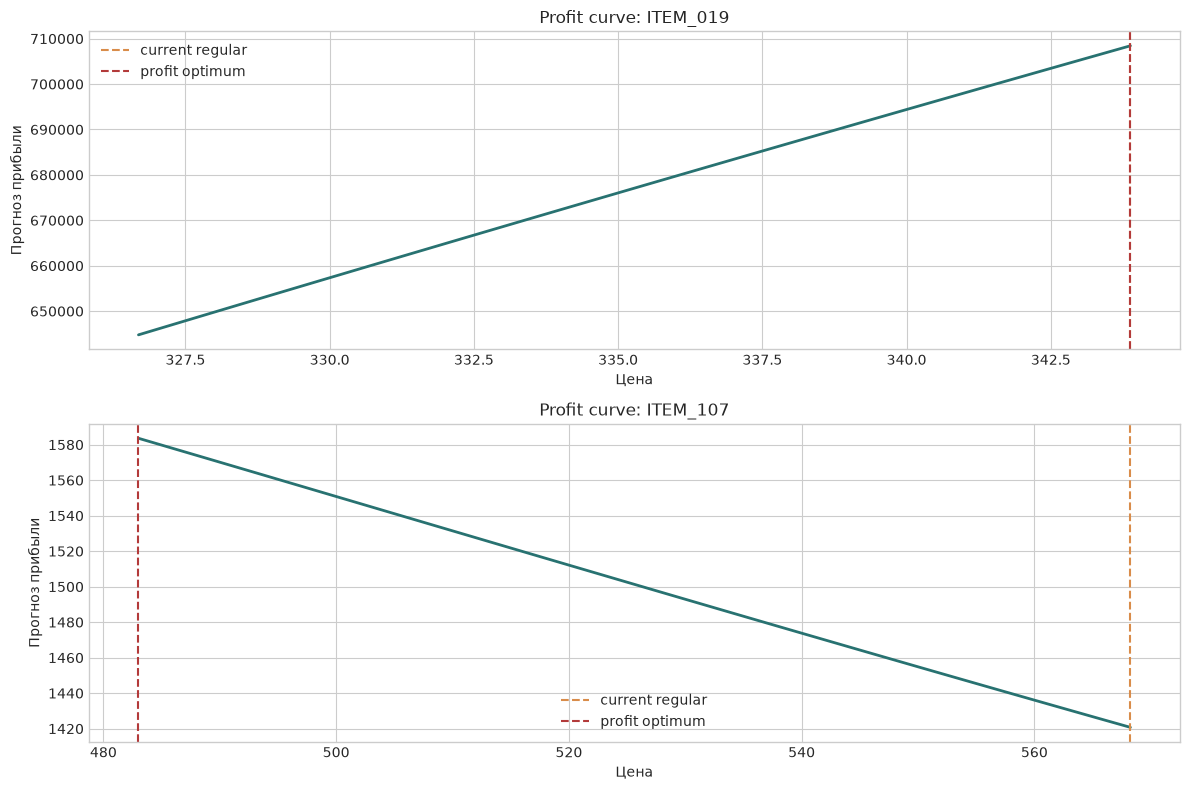

In [11]:
high_volume_item = recommendations.nlargest(1, "base_demand")["item_id"].iloc[0]
elastic_item = recommendations.nsmallest(1, "elasticity")["item_id"].iloc[0]
plot_items = list(dict.fromkeys([high_volume_item, elastic_item]))

fig, axes = plt.subplots(len(plot_items), 1, figsize=(12, 4 * len(plot_items)), squeeze=False)
for ax, item_id in zip(axes.ravel(), plot_items):
    curve = price_curves[price_curves["item_id"].eq(item_id)]
    rec = recommendations[recommendations["item_id"].eq(item_id)].iloc[0]
    ax.plot(curve["candidate_price"], curve["predicted_profit"], color="#287271", linewidth=2)
    ax.axvline(rec["current_regular_price"], color="#D98C4A", linestyle="--", label="current regular")
    ax.axvline(rec["profit_optimal_price"], color="#B33A3A", linestyle="--", label="profit optimum")
    ax.set_title(f"Profit curve: {item_id}")
    ax.set_xlabel("Цена")
    ax.set_ylabel("Прогноз прибыли")
    ax.legend()

plt.tight_layout()
plt.show()

## Выводы и production-план

1. Причинный rolling-score хорошо отделяет крупные технические всплески. Неожиданные нули требуют отдельного правила и журнала доступности товара/ETL-сбоев.
2. Контекст промо отделяет реальные бизнес-всплески от технических ошибок и резко сокращает число ложных high-confidence алертов.
3. Дополнительные причинные лаги, EWM, недельная сезонность и promo-history улучшают глобальную табличную модель относительно rolling baseline. Прямая MAE-цель дополнительно снизила WAPE с 0.3523 до 0.3477 и SMAPE с 0.4708 до 0.4396 по сравнению с `log1p(sales)` target.
4. Root-cause отчёт намеренно разделяет контекстные драйверы ожидаемого спроса и необъяснённый остаток.
5. Оптимальные цены для продаж, GMV и прибыли различаются. В API следует явно передавать выбранную бизнес-цель.
6. Offline-оптимизация не доказывает финансовый uplift. Перед автоматическим rollout нужны shadow mode, ограниченный A/B-тест, мониторинг маржи, WAPE, доли guardrail-срабатываний и drift эластичности.

Созданные артефакты:

- `artifacts/root_cause_report.csv`;
- `artifacts/elasticity_estimates.csv`;
- `artifacts/price_recommendations.csv`.